In [4]:
import sys

print(sys.executable)

C:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
import sys

!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.6.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached curl_cffi-0.16.0-cp310-abi3-win_amd64.whl.metadata (17 kB)
  Using cached lxml-6.1.1-cp313-cp313-win_amd64.whl.metadata (3.6 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.3.0-py3-none-any.whl.metadata (10 kB)
Using cached yfinance-1.6.0-py3-none-any.whl (148 kB)
Using cached curl_cffi-0.16.0-cp310-abi3-win_amd64.whl (2.0 MB)
Using cached lxml-6.1.1-cp313-cp313-win_amd64.whl (4.0 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.3.0-py3-none-any.whl (179 kB)

   ---------------------------------------- 0/7 [pytz]
   ---------------------------------------- 0/7 [pytz]
   ---------------------------------------- 0/7 [pytz]
   ---------------------------------------- 0/7 [pytz]
   ---------------------------------------- 0/7 [pytz]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [6]:
import yfinance as yf
import pandas as pd

print("yfinance is working!")

yfinance is working!


In [7]:
gold = yf.download(
    "GOLDBEES.NS",
    start="2009-01-01",
    end="2026-08-19",
    auto_adjust=False
)

gold.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOLDBEES.NS,GOLDBEES.NS,GOLDBEES.NS,GOLDBEES.NS,GOLDBEES.NS,GOLDBEES.NS
Date,,,,,,
2009-01-02,13.3700,13.3700,13.43,13.3000,0.0,1043400
2009-01-05,13.1555,13.1555,13.32,13.1500,0.0,1294700
2009-01-06,13.0400,13.0400,13.20,13.0201,0.0,1236000
2009-01-07,13.2150,13.2150,13.25,13.0600,0.0,1109000
2009-01-09,13.1689,13.1689,13.20,13.0600,0.0,723900


In [8]:
print("Number of rows:", len(gold))
print("Start date:", gold.index.min())
print("End date:", gold.index.max())
print("\nColumns:")
print(gold.columns)


Number of rows: 4345
Start date: 2009-01-02 00:00:00
End date: 2026-08-18 00:00:00

Columns:
MultiIndex([('Adj Close', 'GOLDBEES.NS'),
            (    'Close', 'GOLDBEES.NS'),
            (     'High', 'GOLDBEES.NS'),
            (      'Low', 'GOLDBEES.NS'),
            (     'Open', 'GOLDBEES.NS'),
            (   'Volume', 'GOLDBEES.NS')],
           names=['Price', 'Ticker'])


In [9]:
# Remove the second level of the column names
gold.columns = gold.columns.get_level_values(0)

# Check the columns
print(gold.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [10]:
# Convert the Date index into a normal column
gold = gold.reset_index()

gold.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2009-01-02,13.3700,13.3700,13.43,13.3000,0.0,1043400
1,2009-01-05,13.1555,13.1555,13.32,13.1500,0.0,1294700
2,2009-01-06,13.0400,13.0400,13.20,13.0201,0.0,1236000
3,2009-01-07,13.2150,13.2150,13.25,13.0600,0.0,1109000
4,2009-01-09,13.1689,13.1689,13.20,13.0600,0.0,723900


In [11]:
gold.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       4345 non-null   datetime64[s]
 1   Adj Close  4345 non-null   float64      
 2   Close      4345 non-null   float64      
 3   High       4345 non-null   float64      
 4   Low        4345 non-null   float64      
 5   Open       4345 non-null   float64      
 6   Volume     4345 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 237.7 KB


In [12]:
gold.isnull().sum()

Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [13]:
print("Duplicate rows:", gold.duplicated().sum())

Duplicate rows: 0


In [14]:
silver = yf.download(
    "SILVERBEES.NS",
    start="2022-01-01",
    end="2026-08-19",
    auto_adjust=False
)

silver.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SILVERBEES.NS,SILVERBEES.NS,SILVERBEES.NS,SILVERBEES.NS,SILVERBEES.NS,SILVERBEES.NS
Date,,,,,,
2022-02-04,60.959599,60.959599,60.959599,60.959599,60.959599,0
2022-02-07,61.770000,61.770000,64.339996,59.439999,60.000000,208834
2022-02-08,62.279999,62.279999,63.000000,61.549999,62.000000,65666
2022-02-09,62.770000,62.770000,63.000000,62.009998,62.500000,156227
2022-02-10,62.799999,62.799999,64.900002,62.200001,63.000000,341078


In [15]:
print("Number of rows:", len(silver))
print("Start date:", silver.index.min())
print("End date:", silver.index.max())

Number of rows: 1121
Start date: 2022-02-04 00:00:00
End date: 2026-08-18 00:00:00


In [16]:
silver.columns

MultiIndex([('Adj Close', 'SILVERBEES.NS'),
            (    'Close', 'SILVERBEES.NS'),
            (     'High', 'SILVERBEES.NS'),
            (      'Low', 'SILVERBEES.NS'),
            (     'Open', 'SILVERBEES.NS'),
            (   'Volume', 'SILVERBEES.NS')],
           names=['Price', 'Ticker'])

In [17]:
silver.columns = silver.columns.get_level_values(0)

silver = silver.reset_index()

silver.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2022-02-04,60.959599,60.959599,60.959599,60.959599,60.959599,0
1,2022-02-07,61.770000,61.770000,64.339996,59.439999,60.000000,208834
2,2022-02-08,62.279999,62.279999,63.000000,61.549999,62.000000,65666
3,2022-02-09,62.770000,62.770000,63.000000,62.009998,62.500000,156227
4,2022-02-10,62.799999,62.799999,64.900002,62.200001,63.000000,341078


In [18]:
# Remove the extra Ticker level from Gold columns
gold.columns = gold.columns.get_level_values(0)

# Convert Date from index to a normal column
gold = gold.reset_index()

# Make sure Date is datetime
gold["Date"] = pd.to_datetime(gold["Date"])

gold.head()

Price,index,Date,Adj Close,Close,High,Low,Open,Volume
0,0,2009-01-02,13.3700,13.3700,13.43,13.3000,0.0,1043400
1,1,2009-01-05,13.1555,13.1555,13.32,13.1500,0.0,1294700
2,2,2009-01-06,13.0400,13.0400,13.20,13.0201,0.0,1236000
3,3,2009-01-07,13.2150,13.2150,13.25,13.0600,0.0,1109000
4,4,2009-01-09,13.1689,13.1689,13.20,13.0600,0.0,723900


In [19]:
# Remove the extra Ticker level from Silver columns
silver.columns = silver.columns.get_level_values(0)

# Convert Date from index to a normal column
silver = silver.reset_index()

# Make sure Date is datetime
silver["Date"] = pd.to_datetime(silver["Date"])

silver.head()

Price,index,Date,Adj Close,Close,High,Low,Open,Volume
0,0,2022-02-04,60.959599,60.959599,60.959599,60.959599,60.959599,0
1,1,2022-02-07,61.770000,61.770000,64.339996,59.439999,60.000000,208834
2,2,2022-02-08,62.279999,62.279999,63.000000,61.549999,62.000000,65666
3,3,2022-02-09,62.770000,62.770000,63.000000,62.009998,62.500000,156227
4,4,2022-02-10,62.799999,62.799999,64.900002,62.200001,63.000000,341078


In [20]:
print("GOLD")
print(gold.shape)
print(gold.dtypes)

print("\nSILVER")
print(silver.shape)
print(silver.dtypes)

GOLD
(4345, 8)
Price
index                int64
Date         datetime64[s]
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
dtype: object

SILVER
(1121, 8)
Price
index                int64
Date         datetime64[s]
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
dtype: object


In [21]:
print("Gold missing values:")
print(gold.isnull().sum())

print("\nSilver missing values:")
print(silver.isnull().sum())

Gold missing values:
Price
index        0
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Silver missing values:
Price
index        0
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [22]:
print("Gold duplicates:", gold.duplicated().sum())
print("Silver duplicates:", silver.duplicated().sum())

Gold duplicates: 0
Silver duplicates: 0


In [23]:
# Find the common date range
common_start = max(gold["Date"].min(), silver["Date"].min())
common_end = min(gold["Date"].max(), silver["Date"].max())

print("Common Start Date:", common_start)
print("Common End Date:", common_end)

Common Start Date: 2022-02-04 00:00:00
Common End Date: 2026-08-18 00:00:00


In [24]:
gold_common = gold[
    (gold["Date"] >= common_start) &
    (gold["Date"] <= common_end)
].copy()

In [25]:
silver_common = silver[
    (silver["Date"] >= common_start) &
    (silver["Date"] <= common_end)
].copy()

In [26]:
print("Gold comparison rows:", len(gold_common))
print("Silver comparison rows:", len(silver_common))

Gold comparison rows: 1121
Silver comparison rows: 1121


In [27]:
print("Gold comparison rows:", len(gold_common))
print("Silver comparison rows:", len(silver_common))

Gold comparison rows: 1121
Silver comparison rows: 1121


In [28]:
gold_common["Daily_Return"] = (
    gold_common["Adj Close"].pct_change() * 100
)

gold_common[["Date", "Adj Close", "Daily_Return"]].head()

Price,Date,Adj Close,Daily_Return
3224,2022-02-04,41.599998,NaN
3225,2022-02-07,41.630001,0.072122
3226,2022-02-08,41.820000,0.456398
3227,2022-02-09,41.990002,0.406509
3228,2022-02-10,42.169998,0.428665


In [29]:
silver_common["Daily_Return"] = (
    silver_common["Adj Close"].pct_change() * 100
)

silver_common[["Date", "Adj Close", "Daily_Return"]].head()

Price,Date,Adj Close,Daily_Return
0,2022-02-04,60.959599,NaN
1,2022-02-07,61.770000,1.329408
2,2022-02-08,62.279999,0.825641
3,2022-02-09,62.770000,0.786772
4,2022-02-10,62.799999,0.047792


In [30]:
gold_common = gold_common.dropna(subset=["Daily_Return"]).copy()
silver_common = silver_common.dropna(subset=["Daily_Return"]).copy()

In [31]:
print("Gold rows:", len(gold_common))
print("Silver rows:", len(silver_common))

Gold rows: 1120
Silver rows: 1120


In [32]:
gold_common["Cumulative_Return"] = (
    (1 + gold_common["Daily_Return"] / 100).cumprod() - 1
) * 100

In [33]:
silver_common["Cumulative_Return"] = (
    (1 + silver_common["Daily_Return"] / 100).cumprod() - 1
) * 100

In [34]:
print(gold_common[["Date", "Cumulative_Return"]].tail())
print(silver_common[["Date", "Cumulative_Return"]].tail())

Price       Date  Cumulative_Return
4340  2026-08-11         201.730772
4341  2026-08-12         203.966350
4342  2026-08-13         201.634635
4343  2026-08-14         200.793274
4344  2026-08-18         203.918281
Price       Date  Cumulative_Return
1116  2026-08-11         264.700577
1117  2026-08-12         270.343637
1118  2026-08-13         262.485985
1119  2026-08-14         262.896093
1120  2026-08-18         263.552255


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries loaded successfully!")

Visualization libraries loaded successfully!


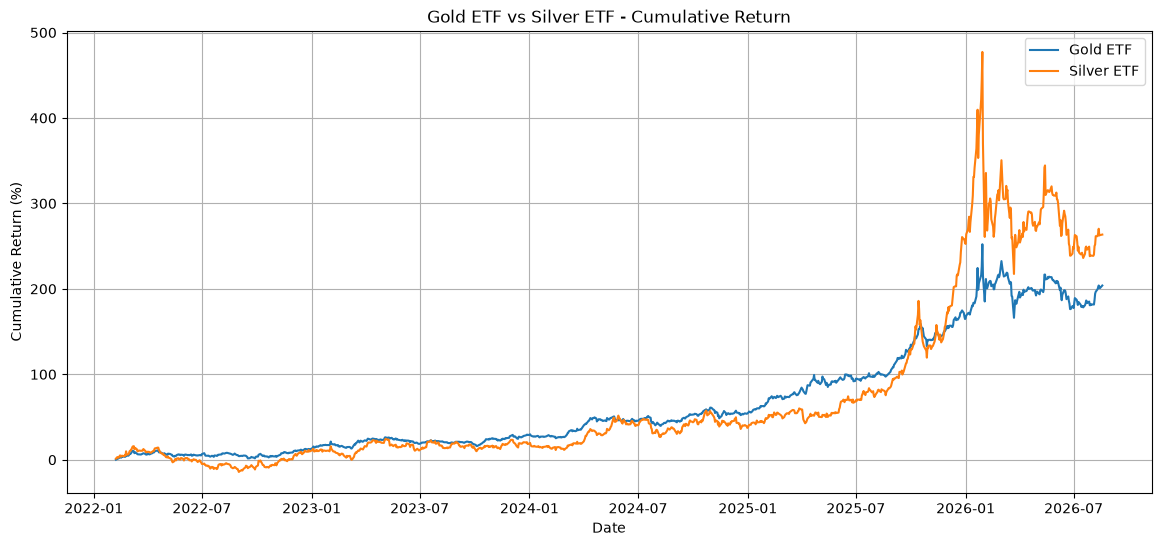

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold_common["Date"],
    gold_common["Cumulative_Return"],
    label="Gold ETF"
)

plt.plot(
    silver_common["Date"],
    silver_common["Cumulative_Return"],
    label="Silver ETF"
)

plt.title("Gold ETF vs Silver ETF - Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
gold_total_return = gold_common["Cumulative_Return"].iloc[-1]
silver_total_return = silver_common["Cumulative_Return"].iloc[-1]

print(f"Gold ETF Total Return: {gold_total_return:.2f}%")
print(f"Silver ETF Total Return: {silver_total_return:.2f}%")

Gold ETF Total Return: 203.92%
Silver ETF Total Return: 263.55%


In [39]:
initial_investment = 100000

gold_common["Investment_Value"] = (
    initial_investment *
    (1 + gold_common["Daily_Return"] / 100).cumprod()
)

silver_common["Investment_Value"] = (
    initial_investment *
    (1 + silver_common["Daily_Return"] / 100).cumprod()
)

print(
    f"Gold ₹1 Lakh Final Value: "
    f"₹{gold_common['Investment_Value'].iloc[-1]:,.2f}"
)

print(
    f"Silver ₹1 Lakh Final Value: "
    f"₹{silver_common['Investment_Value'].iloc[-1]:,.2f}"
)

Gold ₹1 Lakh Final Value: ₹303,918.28
Silver ₹1 Lakh Final Value: ₹363,552.25


In [40]:
gold_common["Year"] = gold_common["Date"].dt.year
silver_common["Year"] = silver_common["Date"].dt.year

In [41]:
gold_yearly = (
    gold_common
    .groupby("Year")["Daily_Return"]
    .apply(lambda x: ((1 + x / 100).prod() - 1) * 100)
)

silver_yearly = (
    silver_common
    .groupby("Year")["Daily_Return"]
    .apply(lambda x: ((1 + x / 100).prod() - 1) * 100)
)

In [43]:
import numpy as np

In [44]:
yearly_comparison = pd.DataFrame({
    "Gold_Return": gold_yearly,
    "Silver_Return": silver_yearly
})

yearly_comparison["Winner"] = np.where(
    yearly_comparison["Gold_Return"] >
    yearly_comparison["Silver_Return"],
    "Gold",
    "Silver"
)

yearly_comparison.round(2)

,Gold_Return,Silver_Return,Winner
Year,,,
2022,12.48,10.29,Gold
2023,14.68,7.36,Gold
2024,19.44,16.00,Gold
2025,71.81,157.29,Silver
2026,14.82,2.87,Gold


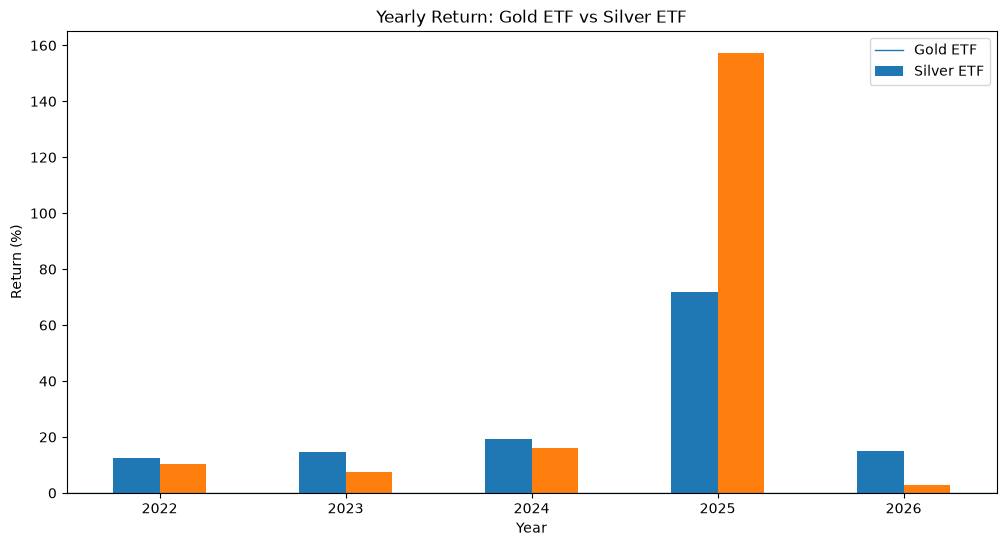

In [45]:
yearly_comparison[["Gold_Return", "Silver_Return"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Yearly Return: Gold ETF vs Silver ETF")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.axhline(0, linewidth=1)
plt.legend(["Gold ETF", "Silver ETF"])
plt.xticks(rotation=0)

plt.show()

In [46]:
gold_volatility = gold_common["Daily_Return"].std()
silver_volatility = silver_common["Daily_Return"].std()

print(f"Gold Daily Volatility: {gold_volatility:.4f}%")
print(f"Silver Daily Volatility: {silver_volatility:.4f}%")

Gold Daily Volatility: 1.1912%
Silver Daily Volatility: 2.1635%


In [47]:
gold_annual_volatility = gold_volatility * np.sqrt(252)
silver_annual_volatility = silver_volatility * np.sqrt(252)

print(f"Gold Annualized Volatility: {gold_annual_volatility:.2f}%")
print(f"Silver Annualized Volatility: {silver_annual_volatility:.2f}%")

Gold Annualized Volatility: 18.91%
Silver Annualized Volatility: 34.34%


In [48]:
gold_common["Running_Peak"] = gold_common["Adj Close"].cummax()

gold_common["Drawdown"] = (
    (gold_common["Adj Close"] - gold_common["Running_Peak"])
    / gold_common["Running_Peak"]
) * 100

In [49]:
silver_common["Running_Peak"] = silver_common["Adj Close"].cummax()

silver_common["Drawdown"] = (
    (silver_common["Adj Close"] - silver_common["Running_Peak"])
    / silver_common["Running_Peak"]
) * 100

In [50]:
gold_max_drawdown = gold_common["Drawdown"].min()
silver_max_drawdown = silver_common["Drawdown"].min()

print(f"Gold Maximum Drawdown: {gold_max_drawdown:.2f}%")
print(f"Silver Maximum Drawdown: {silver_max_drawdown:.2f}%")

Gold Maximum Drawdown: -24.44%
Silver Maximum Drawdown: -45.01%


In [51]:
gold_volatility = gold_common["Daily_Return"].std()
silver_volatility = silver_common["Daily_Return"].std()

gold_annual_volatility = gold_volatility * np.sqrt(252)
silver_annual_volatility = silver_volatility * np.sqrt(252)

print(f"Gold Annualized Volatility: {gold_annual_volatility:.2f}%")
print(f"Silver Annualized Volatility: {silver_annual_volatility:.2f}%")

Gold Annualized Volatility: 18.91%
Silver Annualized Volatility: 34.34%


In [52]:
gold_common["Running_Peak"] = gold_common["Adj Close"].cummax()
gold_common["Drawdown"] = (
    (gold_common["Adj Close"] - gold_common["Running_Peak"])
    / gold_common["Running_Peak"]
) * 100

silver_common["Running_Peak"] = silver_common["Adj Close"].cummax()
silver_common["Drawdown"] = (
    (silver_common["Adj Close"] - silver_common["Running_Peak"])
    / silver_common["Running_Peak"]
) * 100

print(f"Gold Maximum Drawdown: {gold_common['Drawdown'].min():.2f}%")
print(f"Silver Maximum Drawdown: {silver_common['Drawdown'].min():.2f}%")

Gold Maximum Drawdown: -24.44%
Silver Maximum Drawdown: -45.01%


In [53]:
gold_volatility = gold_common["Daily_Return"].std()
silver_volatility = silver_common["Daily_Return"].std()

gold_annual_volatility = gold_volatility * np.sqrt(252)
silver_annual_volatility = silver_volatility * np.sqrt(252)

print(f"Gold Annualized Volatility: {gold_annual_volatility:.2f}%")
print(f"Silver Annualized Volatility: {silver_annual_volatility:.2f}%")

Gold Annualized Volatility: 18.91%
Silver Annualized Volatility: 34.34%


In [54]:
comparison = pd.merge(
    gold_common[["Date", "Daily_Return"]],
    silver_common[["Date", "Daily_Return"]],
    on="Date",
    suffixes=("_Gold", "_Silver")
)

comparison.head()

Price,Date,Daily_Return_Gold,Daily_Return_Silver
0,2022-02-07,0.072122,1.329408
1,2022-02-08,0.456398,0.825641
2,2022-02-09,0.406509,0.786772
3,2022-02-10,0.428665,0.047792
4,2022-02-11,0.047428,-0.700635


In [55]:
correlation = comparison[
    ["Daily_Return_Gold", "Daily_Return_Silver"]
].corr()

print(correlation)

Price                Daily_Return_Gold  Daily_Return_Silver
Price                                                      
Daily_Return_Gold              1.00000              0.81316
Daily_Return_Silver            0.81316              1.00000


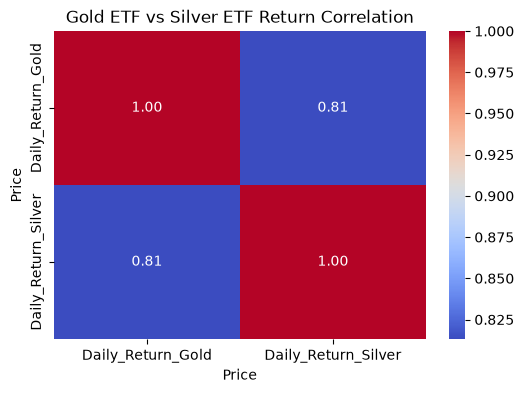

In [56]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Gold ETF vs Silver ETF Return Correlation")
plt.show()

In [57]:
# Annualized volatility
gold_volatility = gold_common["Daily_Return"].std() * np.sqrt(252)
silver_volatility = silver_common["Daily_Return"].std() * np.sqrt(252)

print(f"Gold Annualized Volatility: {gold_volatility:.2f}%")
print(f"Silver Annualized Volatility: {silver_volatility:.2f}%")

Gold Annualized Volatility: 18.91%
Silver Annualized Volatility: 34.34%


In [58]:
# Correlation between Gold and Silver daily returns
comparison = pd.merge(
    gold_common[["Date", "Daily_Return"]],
    silver_common[["Date", "Daily_Return"]],
    on="Date",
    suffixes=("_Gold", "_Silver")
)

correlation = comparison["Daily_Return_Gold"].corr(
    comparison["Daily_Return_Silver"]
)

print(f"Gold-Silver Correlation: {correlation:.2f}")

Gold-Silver Correlation: 0.81


In [60]:
# Create the final Tableau dataset

tableau_data = pd.merge(
    gold_common[
        [
            "Date",
            "Adj Close",
            "Daily_Return",
            "Cumulative_Return",
            "Investment_Value",
            "Drawdown"
        ]
    ],
    silver_common[
        [
            "Date",
            "Adj Close",
            "Daily_Return",
            "Cumulative_Return",
            "Investment_Value",
            "Drawdown"
        ]
    ],
    on="Date",
    suffixes=("_Gold", "_Silver")
)

tableau_data.head()

Price,Date,Adj Close_Gold,Daily_Return_Gold,Cumulative_Return_Gold,Investment_Value_Gold,Drawdown_Gold,Adj Close_Silver,Daily_Return_Silver,Cumulative_Return_Silver,Investment_Value_Silver,Drawdown_Silver
0,2022-02-07,41.630001,0.072122,0.072122,100072.121623,0.0,61.770000,1.329408,1.329408,101329.408224,0.000000
1,2022-02-08,41.820000,0.456398,0.528849,100528.849108,0.0,62.279999,0.825641,2.166025,102166.025154,0.000000
2,2022-02-09,41.990002,0.406509,0.937508,100937.507737,0.0,62.770000,0.786772,2.969839,102969.838975,0.000000
3,2022-02-10,42.169998,0.428665,1.370192,101370.191624,0.0,62.799999,0.047792,3.019050,103019.049895,0.000000
4,2022-02-11,42.189999,0.047428,1.418270,101418.269650,0.0,62.360001,-0.700635,2.297263,102297.262618,-0.700635


In [61]:
tableau_data["Year"] = tableau_data["Date"].dt.year

In [62]:
tableau_data.shape

(1120, 12)

In [63]:
tableau_data.head()

Price,Date,Adj Close_Gold,Daily_Return_Gold,Cumulative_Return_Gold,Investment_Value_Gold,Drawdown_Gold,Adj Close_Silver,Daily_Return_Silver,Cumulative_Return_Silver,Investment_Value_Silver,Drawdown_Silver,Year
0,2022-02-07,41.630001,0.072122,0.072122,100072.121623,0.0,61.770000,1.329408,1.329408,101329.408224,0.000000,2022
1,2022-02-08,41.820000,0.456398,0.528849,100528.849108,0.0,62.279999,0.825641,2.166025,102166.025154,0.000000,2022
2,2022-02-09,41.990002,0.406509,0.937508,100937.507737,0.0,62.770000,0.786772,2.969839,102969.838975,0.000000,2022
3,2022-02-10,42.169998,0.428665,1.370192,101370.191624,0.0,62.799999,0.047792,3.019050,103019.049895,0.000000,2022
4,2022-02-11,42.189999,0.047428,1.418270,101418.269650,0.0,62.360001,-0.700635,2.297263,102297.262618,-0.700635,2022


In [64]:
tableau_data.to_csv(
    "Gold_Silver_Tableau_Data.csv",
    index=False
)

print("Tableau dataset created successfully!")

Tableau dataset created successfully!


In [65]:
import os

print(os.path.abspath("Gold_Silver_Tableau_Data.csv"))

C:\Users\pc\Desktop\Gold_Silver_Tableau_Data.csv
